In [3]:
import json

with open("../data/isoflops_curves.json", "r") as f:
    isoflops_curves = json.load(f)
isoflops_curves

[{'parameters': 49999999,
  'compute_budget': 6e+18,
  'final_loss': 7.192784500319437},
 {'parameters': 78730505,
  'compute_budget': 6e+18,
  'final_loss': 6.750171320661809},
 {'parameters': 123969849,
  'compute_budget': 6e+18,
  'final_loss': 6.406639752150447},
 {'parameters': 195204177,
  'compute_budget': 6e+18,
  'final_loss': 6.154368665155925},
 {'parameters': 307370470,
  'compute_budget': 6e+18,
  'final_loss': 5.987783393573661},
 {'parameters': 483988649,
  'compute_budget': 6e+18,
  'final_loss': 5.903434642394701},
 {'parameters': 762093419,
  'compute_budget': 6e+18,
  'final_loss': 5.899930270214304},
 {'parameters': 1200000000,
  'compute_budget': 6e+18,
  'final_loss': 5.977918696411691},
 {'parameters': 83333333,
  'compute_budget': 1e+19,
  'final_loss': 6.575071254529126},
 {'parameters': 131217508,
  'compute_budget': 1e+19,
  'final_loss': 6.220815025174462},
 {'parameters': 206616415,
  'compute_budget': 1e+19,
  'final_loss': 5.9530019364135125},
 {'paramete

In [ ]:
# extract compute budget to optimal parameters and data
from collections import defaultdict
compute_budget_to_points = defaultdict(list)
for point in isoflops_curves:
    compute_budget_to_points[point["compute_budget"]].append(point)

compute_budget_to_optimal_parameters = {}
compute_budget_to_optimal_data = {}
for compute_budget, points in compute_budget_to_points.items():
    points.sort(key=lambda x: x["final_loss"])
    optimal_parameters = points[0]["parameters"]
    # d = c/6n
    optimal_data = compute_budget / 6 / optimal_parameters
    compute_budget_to_optimal_parameters[compute_budget] = optimal_parameters
    compute_budget_to_optimal_data[compute_budget] = optimal_data

compute_budget_to_optimal_parameters


{6e+18: 762093419,
 1e+19: 806647749,
 3e+19: 1536852354,
 6e+19: 1952041776,
 1e+20: 3253402960,
 3e+20: 5903836027,
 6e+20: 6971055968,
 1e+21: 6859328563,
 3e+21: 12148905329}

In [6]:
# fit the compute budget to optimal parameters and data

import numpy as np
from scipy.optimize import curve_fit

compute_budgets = np.array(list(compute_budget_to_optimal_parameters.keys()))
optimal_parameters = np.array([compute_budget_to_optimal_parameters[c] for c in compute_budgets])
optimal_data = np.array([compute_budget_to_optimal_data[c] for c in compute_budgets])

# fitting function: power law for parameters vs compute budget
def param_power_law(c, a, b):
    return a * c**b

param_popt, param_pcov = curve_fit(param_power_law, compute_budgets, optimal_parameters, maxfev=10000)

def data_power_law(c, a, b):
    return a * c**b

data_popt, data_pcov = curve_fit(data_power_law, compute_budgets, optimal_data, maxfev=10000)

print("Optimal parameters fit coefficients (a, b):", param_popt)
print("Optimal data fit coefficients (a, b):", data_popt)

Optimal parameters fit coefficients (a, b): [25.79296038  0.4038114 ]
Optimal data fit coefficients (a, b): [0.00633759 0.5967707 ]


In [10]:
# Extrapolate to 1e23 and 1e24 flops for both parameters and data
extrap_compute_budgets = np.array([1e23, 1e24])
extrap_parameters = param_power_law(extrap_compute_budgets, *param_popt)
extrap_data = data_power_law(extrap_compute_budgets, *data_popt)

print("Extrapolated compute budgets:", extrap_compute_budgets)
print("Extrapolated parameters:", extrap_parameters)
print("Extrapolated data:", extrap_data)


Extrapolated compute budgets: [1.e+23 1.e+24]
Extrapolated parameters: [5.00222590e+10 1.26757801e+11]
Extrapolated data: [3.37015828e+11 1.33174477e+12]


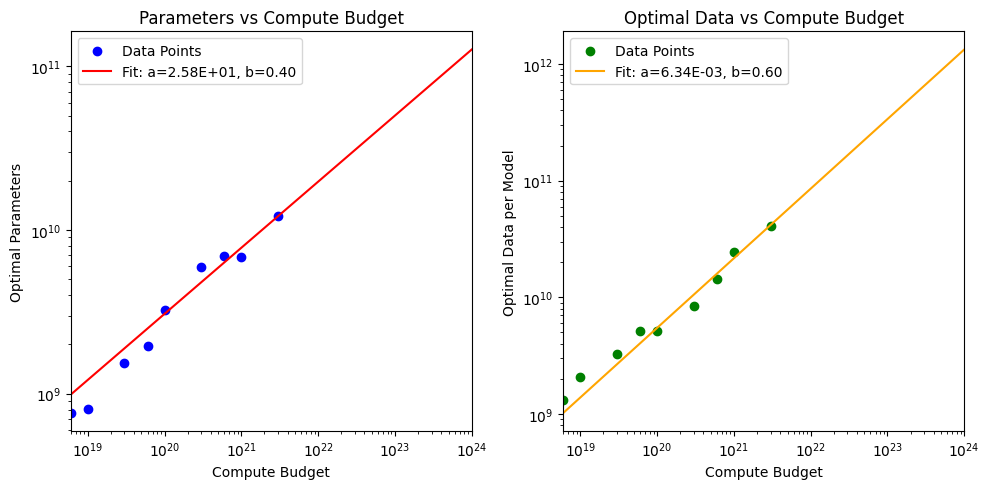

In [ ]:
# plot data and fitted curves for both params and data using previously computed fits
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

xmin = compute_budgets.min()
xmax = 1e24
x_fit = np.logspace(np.log10(xmin), np.log10(xmax), 200)

plt.subplot(1, 2, 1)
plt.scatter(compute_budgets, optimal_parameters, label='Data Points', color='blue')
y_fit = param_power_law(x_fit, *param_popt)
plt.plot(x_fit, y_fit, label=f'Fit: a={param_popt[0]:.2E}, b={param_popt[1]:.2f}', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Compute Budget")
plt.ylabel("Optimal Parameters")
plt.title("Parameters vs Compute Budget")
plt.xlim(xmin, xmax)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(compute_budgets, optimal_data, label='Data Points', color='green')
y_fit = data_power_law(x_fit, *data_popt)
plt.plot(x_fit, y_fit, label=f'Fit: a={data_popt[0]:.2E}, b={data_popt[1]:.2f}', color='orange')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Compute Budget")
plt.ylabel("Optimal Data per Model")
plt.title("Optimal Data vs Compute Budget")
plt.xlim(xmin, xmax)
plt.legend()

plt.tight_layout()
plt.show()